In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('netflix_titles.csv')

In [3]:
df


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


# DATA CLEANING

## Dropping the irrelevent features: 

In [6]:
df=df.drop('show_id',axis=1)
df=df.drop('title',axis=1)
df=df.drop('director',axis=1)
df=df.drop('cast',axis=1)
df=df.drop('date_added',axis=1)
df=df.drop('duration',axis=1)
df=df.drop('description',axis=1)

In [7]:
df

,type,country,release_year,rating,listed_in
0,Movie,United States,2020,PG-13,Documentaries
1,TV Show,South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,NaN,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,NaN,2021,TV-MA,"Docuseries, Reality TV"
4,TV Show,India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...
8802,Movie,United States,2007,R,"Cult Movies, Dramas, Thrillers"
8803,TV Show,NaN,2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies"
8804,Movie,United States,2009,R,"Comedies, Horror Movies"
8805,Movie,United States,2006,PG,"Children & Family Movies, Comedies"


## Converting the datatypes of the columns:

In [9]:
df.dtypes

type            object
country         object
release_year     int64
rating          object
listed_in       object
dtype: object

In [10]:
df['rating']=df['rating'].astype('str')

All the data now is of the correct datatype

## Handling the missing values:

In [13]:
df.isnull().sum()

type              0
country         831
release_year      0
rating            0
listed_in         0
dtype: int64

Here we can see there is only one column which contains missing values i.e. 'country'.

In [15]:
df=df.fillna('others')

In [16]:
df.isnull().sum()

type            0
country         0
release_year    0
rating          0
listed_in       0
dtype: int64

## Changing the names of ambigous columns:

In [18]:
df=df.rename(columns={'listed_in':'genr'})

## EDA(Exploratory Data Analysis)

In [20]:
df.head()

,type,country,release_year,rating,genr
0,Movie,United States,2020,PG-13,Documentaries
1,TV Show,South Africa,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,others,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,others,2021,TV-MA,"Docuseries, Reality TV"
4,TV Show,India,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ..."


In [21]:
df.tail()

,type,country,release_year,rating,genr
8802,Movie,United States,2007,R,"Cult Movies, Dramas, Thrillers"
8803,TV Show,others,2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies"
8804,Movie,United States,2009,R,"Comedies, Horror Movies"
8805,Movie,United States,2006,PG,"Children & Family Movies, Comedies"
8806,Movie,India,2015,TV-14,"Dramas, International Movies, Music & Musicals"


In [22]:
df.shape

(8807, 5)

In [23]:
df.describe(include='object')

,type,country,rating,genr
count,8807,8807,8807,8807
unique,2,749,18,514
top,Movie,United States,TV-MA,"Dramas, International Movies"
freq,6131,2818,3207,362


In [24]:
df.describe(include='all')

,type,country,release_year,rating,genr
count,8807,8807,8807.000000,8807,8807
unique,2,749,NaN,18,514
top,Movie,United States,NaN,TV-MA,"Dramas, International Movies"
freq,6131,2818,NaN,3207,362
mean,NaN,NaN,2014.180198,NaN,NaN
std,NaN,NaN,8.819312,NaN,NaN
min,NaN,NaN,1925.000000,NaN,NaN
25%,NaN,NaN,2013.000000,NaN,NaN
50%,NaN,NaN,2017.000000,NaN,NaN
75%,NaN,NaN,2019.000000,NaN,NaN


In [25]:
df.groupby('genr')['release_year'].count().sort_values(ascending=True)

genr
TV Action & Adventure, TV Comedies, TV Dramas         1
Classic Movies, Dramas, LGBTQ Movies                  1
Classic Movies, Horror Movies, Thrillers              1
Classic Movies, Independent Movies, Thrillers         1
Classic Movies, Music & Musicals                      1
                                                   ... 
Dramas, Independent Movies, International Movies    252
Comedies, Dramas, International Movies              274
Stand-Up Comedy                                     334
Documentaries                                       359
Dramas, International Movies                        362
Name: release_year, Length: 514, dtype: int64

In [26]:
df.groupby('country')['release_year'].count().sort_values(ascending=True)

country
, France, Algeria                            1
Spain, Germany, Denmark, United States       1
Spain, Italy, Argentina                      1
Spain, Mexico, France                        1
Spain, Portugal                              1
                                          ... 
Japan                                      245
United Kingdom                             419
others                                     831
India                                      972
United States                             2818
Name: release_year, Length: 749, dtype: int64

### Content popularity trends

In [28]:
df['country'].value_counts().sort_values(ascending=True)

country
Germany, Canada, United States                                                            1
Ireland, France, Iceland, United States, Mexico, Belgium, United Kingdom, Hong Kong       1
United States, France, Serbia                                                             1
France, Norway, Lebanon, Belgium                                                          1
Sweden, Czech Republic, United Kingdom, Denmark, Netherlands                              1
                                                                                       ... 
Japan                                                                                   245
United Kingdom                                                                          419
others                                                                                  831
India                                                                                   972
United States                                                           

Here, we found that the United states alone have made the largest number of movies among all...

In [30]:
df['genr'].value_counts().sort_values()

genr
Cult Movies, Dramas, Thrillers                                 1
Classic & Cult TV, Kids' TV, Spanish-Language TV Shows         1
International TV Shows, Reality TV, TV Action & Adventure      1
International Movies, Sports Movies                            1
Docuseries, Science & Nature TV, TV Dramas                     1
                                                            ... 
Dramas, Independent Movies, International Movies             252
Comedies, Dramas, International Movies                       274
Stand-Up Comedy                                              334
Documentaries                                                359
Dramas, International Movies                                 362
Name: count, Length: 514, dtype: int64

'Dramas, International Movies' genr is made the most since it is most watches genr.

In [32]:
df['type'].value_counts().sort_values()

type
TV Show    2676
Movie      6131
Name: count, dtype: int64

Movies are watched more than TV Shows

In [34]:
df.groupby('country')['genr'].value_counts().sort_values()

country            genr                                                  
, France, Algeria  Dramas, Independent Movies, International Movies            1
Thailand           International TV Shows, TV Mysteries, TV Thrillers          1
                   International TV Shows, TV Horror, TV Mysteries             1
                   International TV Shows, TV Dramas, TV Sci-Fi & Fantasy      1
                   International TV Shows, TV Dramas, TV Mysteries             1
                                                                            ... 
India              Dramas, Independent Movies, International Movies          108
                   Dramas, International Movies                              118
                   Comedies, Dramas, International Movies                    120
United States      Stand-Up Comedy                                           209
                   Documentaries                                             249
Name: count, Length: 2795, dtype: i

In [35]:
df_copy=df.copy()

In [36]:
df_copy['country']=df_copy['country'].str.split(',')
df_copy['genr']=df_copy['genr'].str.split(',')

In [37]:
df_expanded=df_copy.explode('country').explode('genr')
country_genre_count = df_expanded.groupby(['country', 'genr']).size().reset_index(name='count')

In [38]:
country_genre_count = country_genre_count.sort_values(by='count', ascending=False)
country_genre_count

,country,genr,count
1547,India,International Movies,807
2391,United States,Dramas,429
2389,United States,Documentaries,429
1575,India,Dramas,404
2386,United States,Comedies,374
...,...,...,...
929,United Arab Emirates,Sci-Fi & Fantasy,1
925,United Arab Emirates,Comedies,1
924,Ukraine,Documentaries,1
923,Ukraine,International Movies,1


We can see here, which region has released how many movies of a particular genr and we can conclude many things from here like which genr is liked the most in a particular region or country like in India 'International' movies are watched the most and in United states 'Documentaries' are watched the most.

In [40]:
df_copy2 = df.dropna(subset=['country', 'genr']).copy()
df_copy2['country'] = df_copy2['country'].str.split(', ')
df_copy2['genr'] = df_copy2['genr'].str.split(', ')
df_expanded = df_copy2.explode('country').explode('genr')
grouped = df_expanded.groupby(['country', 'genr']).size().reset_index(name='count')
max_genres = grouped.loc[grouped.groupby('country')['count'].idxmax()]

print(max_genres.sort_values(by='count', ascending=False)) 


             country                    genr  count
526            India    International Movies    864
1351   United States                  Dramas    835
1300  United Kingdom        British TV Shows    225
1439          others  International TV Shows    223
391           France    International Movies    207
...              ...                     ...    ...
1066        Slovakia                  Dramas      1
803       Montenegro                  Dramas      1
1074         Somalia                  Dramas      1
164     Burkina Faso                  Dramas      1
0                                     Dramas      1

[128 rows x 3 columns]


In [41]:
min_genres = grouped.loc[grouped.groupby('country')['count'].idxmin()]
print(min_genres.sort_values(by='count',ascending=False))

             country                      genr  count
1358   United States           Korean TV Shows      3
575             Iraq             Documentaries      2
214   Cayman Islands  Children & Family Movies      2
449            Ghana                  Comedies      2
915           Panama             Documentaries      1
...              ...                       ...    ...
394           France              LGBTQ Movies      1
364          Finland        Action & Adventure      1
361         Ethiopia                    Dramas      1
341            Egypt  Children & Family Movies      1
1427          others         Classic & Cult TV      1

[128 rows x 3 columns]


In [42]:
max_genres_sorted=max_genres.sort_values(by='count',ascending=False)

C:\Users\KARTIK\AppData\Local\Temp\ipykernel_26388\539871788.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


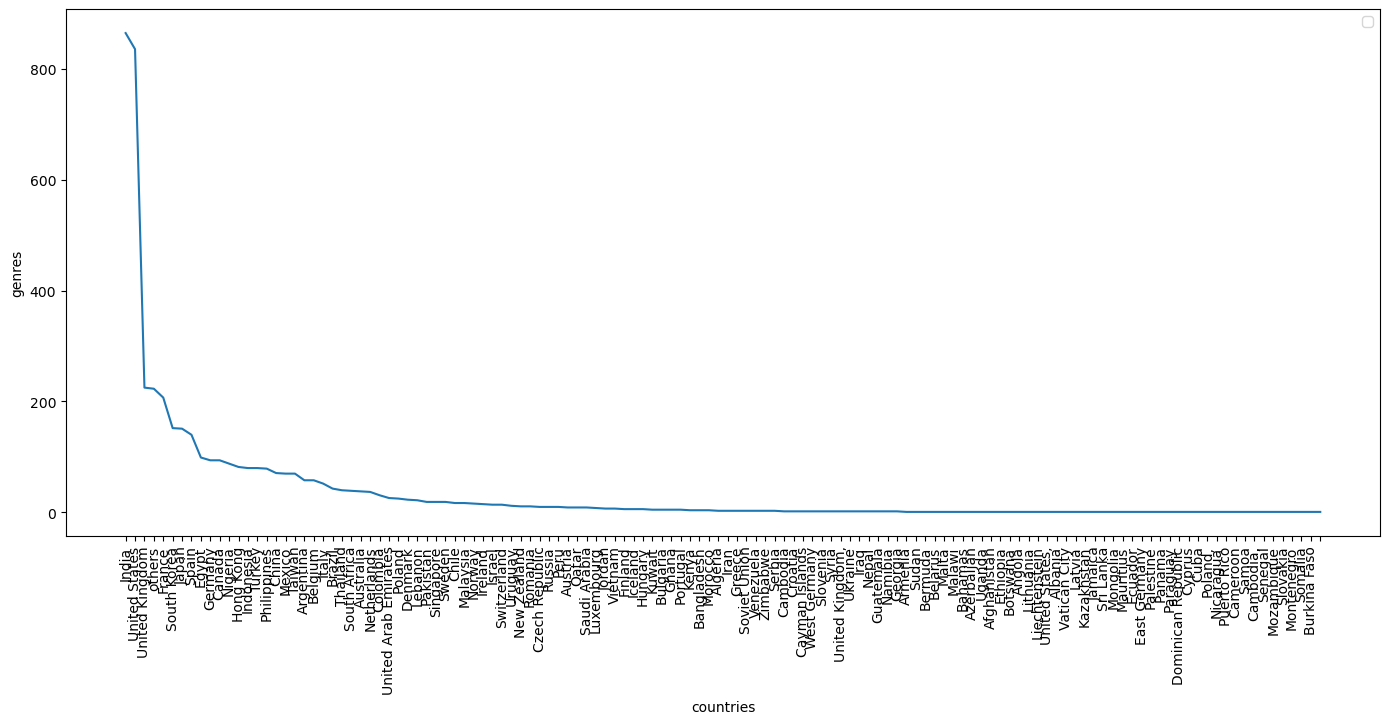

In [61]:
plt.figure(figsize=(14,6))
plt.plot(max_genres_sorted['country'],max_genres_sorted['count'])
plt.xlabel('countries')
plt.ylabel('genres')
plt.tight_layout()
plt.xticks(rotation=90)
plt.legend(loc='upper right')

From these observations we got to know about the genres, which genr is watched most in which country and which genr is watched least in which country like: "International movies" are watched the most in India and 'Dramas' are watched most in the United states. Along with, in United states the least watched genr is 'Korean TV Shows' and in Iran "documentaries" are least watched.

C:\Users\KARTIK\AppData\Local\Temp\ipykernel_26388\1115053301.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


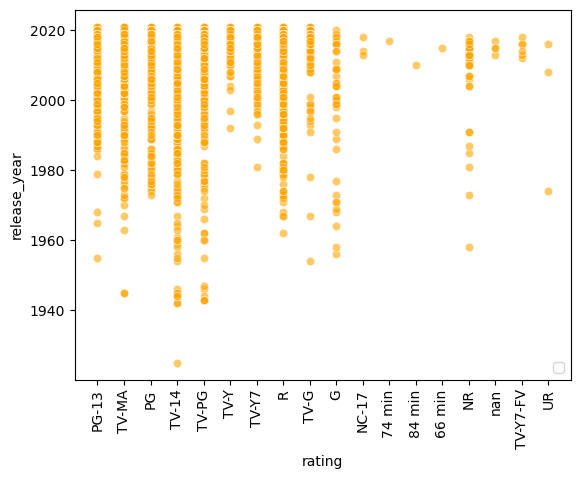

In [63]:
sns.scatterplot(x=df['rating'],y=df['release_year'],alpha=0.6,color='orange')
plt.xticks(rotation=90)
plt.legend(loc='lower right')

From the above plot we can easily conclude that TV-14 is the rating which was kind of constant from the early 1940s and gradually it boomed whereas 74 min, 84 min and 66 min are the three ratings which was never being made except in late 2010s

### Content changed over the time:

From the above scatter plot we can conclude the content have been broadened over the time as in the earlier times TV-14 and TV-PG that means content for the people above 14 and the content can be watched under the supervison of adults was watched only but gradually the crowd of PG-13 and TV-G i.e adult also started watching.

### Country produced the most shows

In [79]:
df.groupby('country')['type'].value_counts().sort_values()

country                                                                          type   
, France, Algeria                                                                Movie         1
Russia, Spain                                                                    Movie         1
Russia, United States                                                            Movie         1
Russia, United States, China                                                     Movie         1
Saudi Arabia, Netherlands, Germany, Jordan, United Arab Emirates, United States  Movie         1
                                                                                            ... 
others                                                                           TV Show     391
                                                                                 Movie       440
United States                                                                    TV Show     760
India                                 

India have made the largest number of TV Shows whereas United states have made the lasrgest number of movies.